# Análisis de Navegación Reactiva - Escenario Complejo

Este notebook tiene como objetivo analizar los datos exportados por el controlador de Webots del robot e-puck. Estudiaremos cómo difieren las señales crudas (raw), las suavizadas por el filtro de promedio móvil (filtered) y la estimación calculada por el Filtro de Kalman.

In [3]:
%pip install pandas matplotlib numpy scipy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de los gráficos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga de los Datos
Leemos los tres archivos CSV generados para el escenario complejo:

In [12]:
# Cargar los datasets
df_raw = pd.read_csv('csv/complejo/lab2_data_raw.csv')
df_filt = pd.read_csv('csv/complejo/lab2_data_filtered.csv')
df_kalman = pd.read_csv('csv/complejo/lab2_data_kalman.csv')

print("Tamaño Raw:", df_raw.shape)
print("Tamaño Filtered:", df_filt.shape)
print("Tamaño Kalman:", df_kalman.shape)

# Visualizar las primeras filas del dataset usando Kalman para navegación
print(df_kalman.head())

print(df_filt.head())

print(df_raw.head())

Tamaño Raw: (5000, 32)
Tamaño Filtered: (5000, 32)
Tamaño Kalman: (5000, 32)
   step  time_s nav_mode  raw_ps0  raw_ps7  raw_ps1  raw_ps6  raw_ps2  \
0     0   0.000   kalman    63.66    69.98    69.73    71.49    63.76   
1     1   0.064   kalman    67.79    67.07    68.71    69.97    71.73   
2     2   0.128   kalman    69.65    65.05    66.60    65.80    62.72   
3     3   0.192   kalman    62.82    70.81    67.04    68.08    64.97   
4     4   0.256   kalman    72.76    64.94    68.85    74.83    63.73   

   raw_ps5  dist_raw_front_R  ...  delta_right  delta_advance  \
0    66.77          0.120000  ...      0.00000       0.000000   
1    70.24          0.059598  ...      0.17584       0.003605   
2    69.75          0.058945  ...      0.18212       0.003669   
3    63.39          0.120000  ...      0.17584       0.003669   
4    64.21          0.057884  ...      0.18212       0.003669   

   kalman_prediction  kalman_estimate  kalman_gain  kalman_P  \
0           0.120000         

## 2. Comparación de las Señales (Cruda vs Promedio Móvil vs Kalman)
Durante el modo `kalman`, el robot de todos modos registró en cada instante las variables de los demás enfoques. Podemos visualizar esto extrayendo un fragmento de tiempo específico (por ejemplo los primeros 10-20 segundos o steps particulares) para ver cómo las tres lógicas perciben la **distancia frontal** de forma distinta.

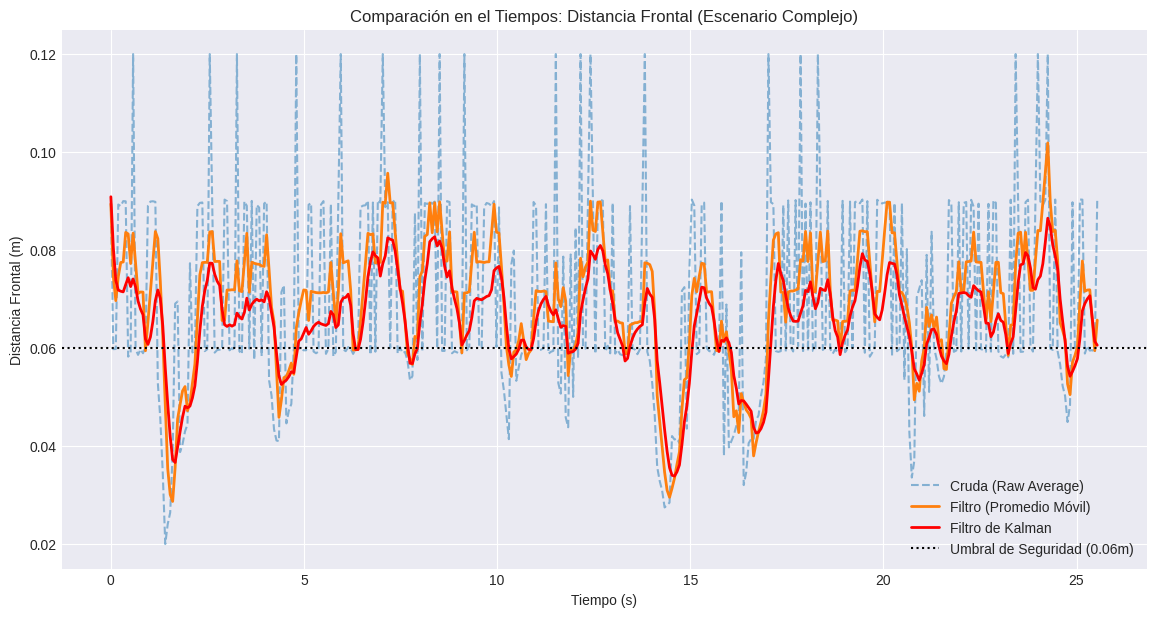

In [13]:
# Extraemos un segmento donde el robot interactúa (por ejemplo primeros 400 pasos)
segment_kalman = df_kalman.iloc[:400]

plt.figure(figsize=(14, 7))
plt.plot(segment_kalman['time_s'], segment_kalman['dist_raw_front_avg'], label='Cruda (Raw Average)', alpha=0.5, linestyle='--')
plt.plot(segment_kalman['time_s'], segment_kalman['dist_filtered_avg'], label='Filtro (Promedio Móvil)', linewidth=2)
plt.plot(segment_kalman['time_s'], segment_kalman['kalman_estimate'], label='Filtro de Kalman', linewidth=2, color='red')

plt.axhline(y=0.06, color='black', linestyle=':', label='Umbral de Seguridad (0.06m)')

plt.title('Comparación en el Tiempos: Distancia Frontal (Escenario Complejo)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia Frontal (m)')
plt.legend()
plt.show()

## 3. Impacto de la Fusión en las Acciones de Navegación
Analizamos la cantidad de veces que el controlador debió aplicar acciones evasivas (`TURN_LEFT`, `TURN_RIGHT`) o si sufrió bloqueos (`STUCK`, `REVERSE`). En teoría, el filtro de Kalman, al estabilizar la señal temporal con los encoders, debería generar una conducción con *menos* oscilaciones y giros innecesarios.

,Raw,Filtered,Kalman
action,,,
FORWARD,32,20,171
FORWARD_CURVE_L,101,76,589
FORWARD_CURVE_R,375,3788,2620
TURN_LEFT,2169,180,882
TURN_RIGHT,2323,936,738


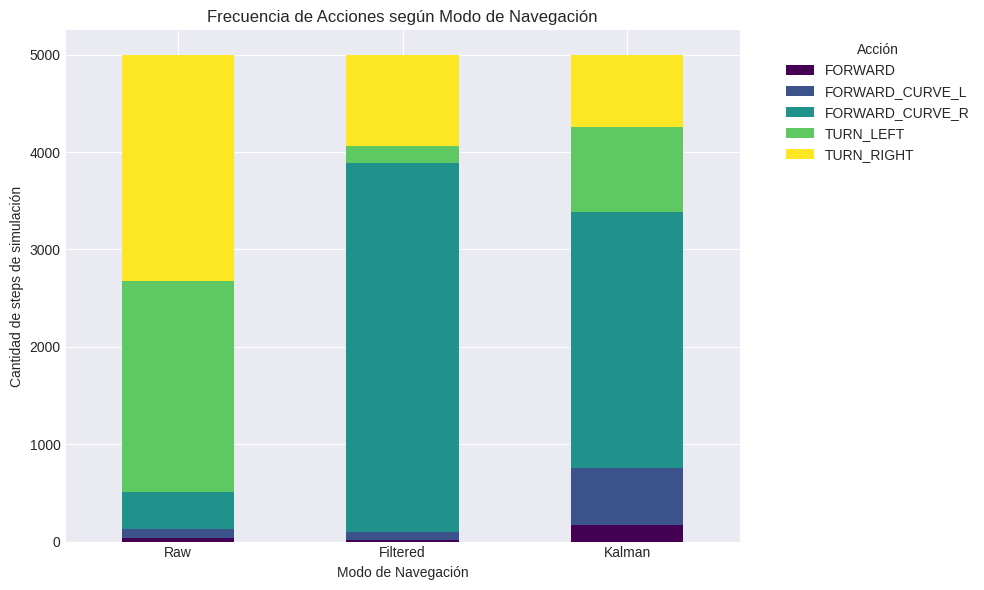

In [14]:
# Analizamos el conteo de acciones en los tres acercamientos
actions_raw = df_raw['action'].value_counts()
actions_filt = df_filt['action'].value_counts()
actions_kalman = df_kalman['action'].value_counts()

df_actions = pd.DataFrame({
    'Raw': actions_raw,
    'Filtered': actions_filt,
    'Kalman': actions_kalman
}).fillna(0)

display(df_actions)

df_actions.T.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Frecuencia de Acciones según Modo de Navegación')
plt.ylabel('Cantidad de steps de simulación')
plt.xlabel('Modo de Navegación')
plt.xticks(rotation=0)
plt.legend(title='Acción', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Evolución de Parámetros del Filtro de Kalman
La Ganancia de Kalman ($K$) y la Covarianza estimada ($P$) se ajustan dinámicamente frente al ruido del proceso ($Q$) y la varianza de medición sensada ($R$).

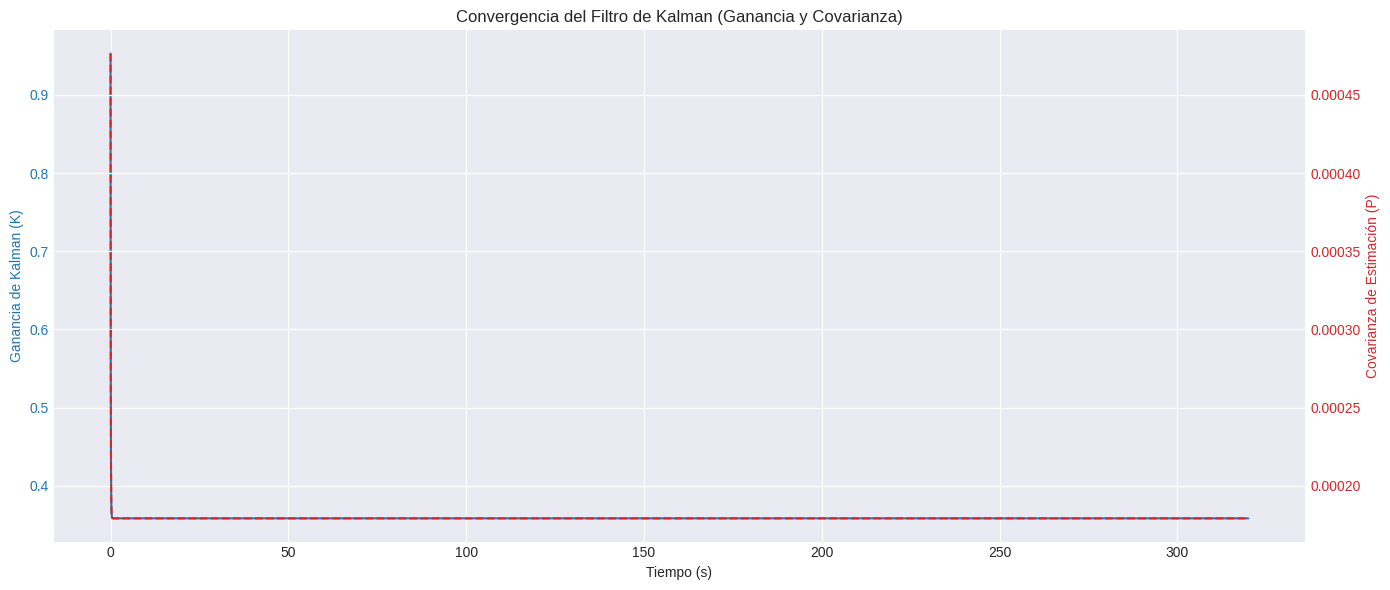

In [15]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Ganancia de Kalman (K)', color=color)
ax1.plot(df_kalman['time_s'], df_kalman['kalman_gain'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Covarianza de Estimación (P)', color=color)
ax2.plot(df_kalman['time_s'], df_kalman['kalman_P'], color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Convergencia del Filtro de Kalman (Ganancia y Covarianza)')
fig.tight_layout()  
plt.show()

## 5. Análisis y Conclusiones a partir de los Gráficos
*(En esta sección elaboraremos las conclusiones basándonos en lo que nos muestren los gráficos de arriba. Ejecuta todas las celdas para descubrir los resultados.)*

1. **Comparación de señales**: ¿Qué tanto ruido tenía la raw frente a la del promedio y kalman? ¿Muestra Kalman retraso?
2. **Impacto en giro**: ¿Cuál estrategia tuvo menos STUCK o REVERSE? ¿Disminuyeron los TURN_LEFT / TURN_RIGHT oscilatorios con Kalman?
3. **Convergencia del filtro**: Si K se estabiliza de inmediato, significa que nuestra varianza de estimación del error llegó a un estado límite (debido a que los valores R y Q en el código `epuck-kalman.py` eran constantes fijas).